# 🛍️ Market Basket Analysis — Online Cosmetics Store
---

## 🎯 Business Request & Goals
Our data shows that customers often buy multiple products together, but our current recommendation system is not capitalizing on this behavior. We are losing cross-selling opportunities, so we need to solve this issue immediately.

**Key Requirements:** Analyze transaction history to:
- Identify the most profitable **product combos**.
- Understand the **shopping psychology** behind these combinations.
- Recommend actionable strategies for **store layout and promotions** to boost sales.

**Method:** Association Rule Mining (Apriori + FP-Growth) using the `mlxtend` library.

## **1. Import library and Load dataframe**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load raw data tables
path = '/content/drive/MyDrive/Analytics/Dataset/CosmeticWorld'
ecom_sales = pd.read_csv(f'{path}/EcomSales.csv')
product_info = pd.read_csv(f'{path}/Product.csv')

# Defensive text normalization: strip whitespace and lowercase Subcategory
# so that case/whitespace variants (e.g. "Hand Creams " vs "hand creams")
# are never silently treated as two different items downstream.
product_info['Subcategory'] = product_info['Subcategory'].str.strip().str.lower()


In [ ]:
ecom_sales.head()

,RowID,OrderID,OrderDate,CustomerID,Segment,RegionCode,ProductCode,Quantity,Sales,Discount,Profit
0,25221,IN-2012-TH211151-41003,4/4/2020,TH-211151,Corporate,RRR0001,P000001,13,416,0.0,208.0
1,29464,ID-2013-BD116051-41518,9/1/2021,BD-116051,Consumer,R0002,PPP000002,4,20,0.0,10.0
2,27311,IN-2015-TS212051-42173,6/18/2023,TS-212051,Corporate,R0003,P000003,2,20,0.0,8.0
3,28882,IN-2014-SU206651-41899,9/17/2022,SU-206651,Self-Employed,R0003,P000004,4,556,0.0,55.6
4,27992,IN-2015-GM144551-42217,8/1/2023,GM-144551,Self-Employed,R0003,P000005,2,6,0.0,0.6


In [ ]:
product_info.head()

,ProductCode,Product,Category,Subcategory
0,P000001,Soap & Glory Endless Glove Moisturizing Hand C...,Body care,"bath oils, bubbles and soaks"
1,P000002,Pantene Pro-V Truly Relaxed Hair Lightweight C...,Body care,"bath oils, bubbles and soaks"
2,P000003,Estée Lauder Pure Color Envy Irresistible,Body care,"bath oils, bubbles and soaks"
3,P000004,Gold Infinity Bracelet,Body care,body moisturizers
4,P000005,Deborah Lippmann Nail Polish Lady is a Tramp C...,Body care,body moisturizers


## **2. Data Description**

| Table | Description | Key Columns |
|------|-------|---------------|
| `EcomSales.csv` | Transaction history | OrderID, OrderDate, ProductCode, Quantity, Revenue |
| `Product.csv` | Product information | ProductCode, Product, Subcategory, Category |

> **Analysis Note:** We will analyze the data at the **Subcategory** level instead of looking at specific products. This is because products in the same subcategory usually meet the same customer needs.

In [ ]:
print('--- Ecom Sales DataFrame Info ---')
ecom_sales.info()
print('\n--- Missing Values in Ecom Sales ---')
print(ecom_sales.isna().sum())
print('\n--- Duplicate Records in Ecom Sales ---')
print(ecom_sales.duplicated().sum())

--- Ecom Sales DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   RowID        51290 non-null  int64  
 1   OrderID      51290 non-null  object 
 2   OrderDate    51290 non-null  object 
 3   CustomerID   51290 non-null  object 
 4   Segment      51290 non-null  object 
 5   RegionCode   51290 non-null  object 
 6   ProductCode  51290 non-null  object 
 7   Quantity     51290 non-null  int64  
 8   Sales        51290 non-null  int64  
 9   Discount     51290 non-null  float64
 10  Profit       51290 non-null  float64
dtypes: float64(2), int64(3), object(6)
memory usage: 4.3+ MB

--- Missing Values in Ecom Sales ---
RowID          0
OrderID        0
OrderDate      0
CustomerID     0
Segment        0
RegionCode     0
ProductCode    0
Quantity       0
Sales          0
Discount       0
Profit         0
dtype: int64

--- Duplic

In [ ]:
print('\n\n--- Product Info DataFrame Info ---')
product_info.info()
print('\n--- Missing Values in Product Info ---')
print(product_info.isna().sum())
print('\n--- Duplicate Records in Product Info ---')
print(product_info.duplicated().sum())



--- Product Info DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28356 entries, 0 to 28355
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ProductCode  28356 non-null  object
 1   Product      28356 non-null  object
 2   Category     28356 non-null  object
 3   Subcategory  28356 non-null  object
dtypes: object(4)
memory usage: 886.3+ KB

--- Missing Values in Product Info ---
ProductCode    0
Product        0
Category       0
Subcategory    0
dtype: int64

--- Duplicate Records in Product Info ---
0


In [ ]:
product_info['Product'].nunique()

3577

In [ ]:
product_info['Subcategory'].nunique()

17

In [ ]:
product_info['Category'].nunique()

5

In [ ]:
ecom_sales['OrderDate'] = ecom_sales['OrderDate'].astype('datetime64[ns]')
ecom_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   RowID        51290 non-null  int64         
 1   OrderID      51290 non-null  object        
 2   OrderDate    51290 non-null  datetime64[ns]
 3   CustomerID   51290 non-null  object        
 4   Segment      51290 non-null  object        
 5   RegionCode   51290 non-null  object        
 6   ProductCode  51290 non-null  object        
 7   Quantity     51290 non-null  int64         
 8   Sales        51290 non-null  int64         
 9   Discount     51290 non-null  float64       
 10  Profit       51290 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 4.3+ MB


### 🔍 EDA Observations
- **Ecom Sales:** 51,290 rows, 11 columns — no missing values, no full-row duplicates
- **Product Info:** 3,577 products belonging to 17 Subcategories and 5 Categories
- `Subcategory` values have been stripped and lowercased to avoid case/whitespace variants
- The `OrderDate` column has been converted to `datetime64` for time processing

> ✅ The data looks clean at first pass — but we still validate for hidden duplicates
> introduced *after* the merge step below, since `ecom_sales.duplicated()` above only
> checks full-row duplicates, not duplicate `(OrderID, ProductCode)` business keys.


### 🧹 A Reusable Cleaning-Check Function

The checks above (`.duplicated().sum()`, `.isna().sum()`) are written ad hoc for each table.
Since we'll need the same kind of check on other dataframes later in this notebook — not
just these two raw tables — it's worth wrapping it into one reusable function now, so every
check in this notebook reports the same information the same way.


In [ ]:
def cleaning_dataframe(df, subset=None):
    """
    Generic data-quality check for any dataframe.
    - subset=None -> checks full-row duplicates (default pandas behavior)
    - subset=[...] -> checks duplicates on a specific business key instead
    Returns a dict of the diagnostics (not just prints them), so the caller
    can decide what to do with the result rather than the function deciding for them.
    """
    missing = df.isna().sum()
    missing = missing[missing > 0]

    dup_count = df.duplicated(subset=subset).sum()
    scope = 'full row' if subset is None else f'subset={subset}'

    print(f"Rows: {len(df)}")
    print(f"Duplicate rows ({scope}): {dup_count}")
    print("Missing values:", "none" if missing.empty else f"\n{missing}")

    return {
        'n_rows': len(df),
        'duplicate_rows': dup_count,
        'duplicate_scope': scope,
        'missing_values': missing,
    }


# Sanity-check the function against the two raw tables
_ = cleaning_dataframe(ecom_sales)
print()
_ = cleaning_dataframe(product_info)


Rows: 51290
Duplicate rows (full row): 0
Missing values: none

Rows: 28356
Duplicate rows (full row): 0
Missing values: none


## **3. Apriori (using mlxtend)**

## **⚙️ Parameter Selection**

| Parameter | Value | Reason for Choice |
|---------|---------|------------|
| `min_support` | 0.001 | Dataset: **51,290 rows** / **17 subcategories**.<br>A combo must appear at least **~51 times** to be frequent.<br>This avoids noise while keeping potential combos. |
| `metric` | `lift` | Lift > 1 means the two subcategories appear together more often than random. |
| `min_threshold` | 1.2 | Filter to keep only the rules with clear connections. |

**Explanation of the 3 Key Metrics:**
- **Support:** The percentage of orders that contain this combo (popularity).
- **Confidence:** If a customer buys A, the probability that they will also buy B (reliability).  
- **Lift:** How many times the purchase of A increases the chance of buying B compared to random chance.

**MARKET BASKET ANALYSIS (MBA) WITH MLXTEND**

### **Step 1: Importing Required Libraries**
We will use `pandas` for data processing and `mlxtend` to run the Apriori algorithm and extract association rules.

In [ ]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.frequent_patterns import fpgrowth, association_rules

import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

### **Step 2: Loading and exploring the data**
Load the sales data and product information, then combine them to get detailed product names.

### 🔎 Why We Check Duplicates Again, Right Here

`cleaning_dataframe()` already confirmed both raw tables are clean — 0 full-row duplicates.
But a `merge()` is a join, and a join can produce duplicate rows **even when both input
tables were individually clean**, in two different ways:

1. If `ecom_sales` has more than one row sharing the same `(OrderID, ProductCode)` — not a
   full-row duplicate (other columns like `RowID` differ), so Section 2's check couldn't
   have caught it — the merge just carries both rows through untouched.
2. If a single `ProductCode` in `product_info` maps to more than one `Subcategory`, the join
   fans out: one `ecom_sales` row becomes two or more rows in `df`, each with a different
   `Subcategory` for what was really one purchase.

Neither of these is visible until *after* the merge, so we re-run the same check here — this
time keyed on `(OrderID, ProductCode)`, the business key that actually matters once we start
building baskets in Section 3.


In [ ]:
df = pd.merge(ecom_sales[['OrderID', 'ProductCode']],
              product_info[['ProductCode', 'Product', 'Subcategory']],
              on='ProductCode', how='inner')

report = cleaning_dataframe(df, subset=['OrderID', 'ProductCode'])

# Separate check: does a single ProductCode ever map to more than one Subcategory?
# (cleaning_dataframe() only flags duplicate ROWS -- this checks a different thing,
# a one-to-many relationship in product_info that a plain duplicate check can't see.)
fanout = product_info.groupby('ProductCode')['Subcategory'].nunique()
bad_products = fanout[fanout > 1]
print(f"\nProductCode(s) mapping to more than one Subcategory: {len(bad_products)}")
if len(bad_products) > 0:
    print(f"  -> needs manual review before trusting the rules: {bad_products.index.tolist()[:5]}")


Rows: 51288
Duplicate rows (subset=['OrderID', 'ProductCode']): 102
Missing values: none

ProductCode(s) mapping to more than one Subcategory: 0


Based on the check above: if `bad_products` came back empty, the duplication is coming
purely from `ecom_sales` business-key repeats (case 1), which is safe to drop — it doesn't
change *which* subcategories a customer bought, only how many times the same line item was
logged. If `bad_products` is **not** empty, that needs to be resolved in `product_info`
first (e.g. picking the correct Subcategory per product with the business), since blindly
dropping duplicates would keep an arbitrary Subcategory with no warning.


In [ ]:
n_before = len(df)
df = df.drop_duplicates(subset=['OrderID', 'ProductCode'], keep='first').reset_index(drop=True)
print(f"{n_before} rows -> {len(df)} rows after dropping duplicate (OrderID, ProductCode) pairs")


51288 rows -> 51186 rows after dropping duplicate (OrderID, ProductCode) pairs


In [ ]:
df.head()

,OrderID,ProductCode,Product,Subcategory
0,IN-2012-TH211151-41003,P000001,Soap & Glory Endless Glove Moisturizing Hand C...,"bath oils, bubbles and soaks"
1,IN-2015-TS212051-42173,P000003,Estée Lauder Pure Color Envy Irresistible,"bath oils, bubbles and soaks"
2,IN-2014-SU206651-41899,P000004,Gold Infinity Bracelet,body moisturizers
3,IN-2015-GM144551-42217,P000005,Deborah Lippmann Nail Polish Lady is a Tramp C...,body moisturizers
4,IN-2015-CA120551-42085,P000006,Urban Decay Vice Lipstick Rock Steady,body soaps and washes


### **Step 3: Group Items by Transaction**
Unlike the Groceries dataset (which is grouped by date), here we group products bought together based on the order ID (`OrderID`).

In [ ]:
# Group purchased items by OrderID to build the basket list
basket = df.groupby('OrderID')['Subcategory'].apply(list).reset_index()
transactions = basket['Subcategory'].tolist()

print(f"Total baskets (unique orders): {len(transactions)}")


Total baskets (unique orders): 25728


In [ ]:
transactions

[['hand creams', 'face masks and exfoliators'],
 ['candles, sprays, diffusers', 'nail care products'],
 ['shampoos and conditioners', 'hand creams'],
 ['nail care products',
  'shampoos and conditioners',
  'nail care products',
  'hair colors and toners',
  'vitamins and supplements',
  'nail care products'],
 ['nail care products'],
 ['face masks and exfoliators'],
 ['vitamins and supplements'],
 ['eye shadows and pencils'],
 ['brushes and applicators'],
 ['bath oils, bubbles and soaks'],
 ['nail care products'],
 ['body moisturizers'],
 ['foundations and concealers'],
 ['body moisturizers', 'shampoos and conditioners', 'eye shadows and pencils'],
 ['hair colors and toners'],
 ['nail care products'],
 ['nail care products', 'face moisturizing products'],
 ['body soaps and washes'],
 ['hair colors and toners', 'candles, sprays, diffusers', 'lipsticks'],
 ['face moisturizing products'],
 ['body moisturizers'],
 ['vitamins and supplements'],
 ['foundations and concealers'],
 ['body mois

### **Step 4: Convert to One-Hot Format**
Use `TransactionEncoder` to convert the product list into a True/False matrix (One-Hot), which is the required format for the Apriori algorithm.

In [ ]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

In [ ]:
df_encoded.head()

,accessories,"bath oils, bubbles and soaks",body moisturizers,body soaps and washes,brushes and applicators,"candles, sprays, diffusers",eye shadows and pencils,face masks and exfoliators,face moisturizing products,foundations and concealers,fragrances,hair colors and toners,hand creams,lipsticks,nail care products,shampoos and conditioners,vitamins and supplements
0,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,True
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


### **Step 5: Run Apriori Algorithm**
We will now find the frequent itemsets. As planned above, we use `min_support=0.001` (meaning the combo appears in at least 0.1% of all orders) because our e-commerce dataset is large and diverse.

In [ ]:
frequent_itemsets = apriori(df_encoded, min_support=0.001, use_colnames=True)
print("Total Frequent Itemsets:", frequent_itemsets.shape[0])

Total Frequent Itemsets: 612


### **Step 6: Generate Association Rules**
Create rules based on the `lift` metric to find the strongest connections between products.

In [ ]:
from mlxtend.frequent_patterns import association_rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)
print("Association Rules:", rules.shape[0])

Association Rules: 2424


In [ ]:
rules.sort_values(by='lift', ascending=False)[['antecedents', 'consequents', 'support', 'confidence', 'lift']].reset_index(drop=True).head(10)

,antecedents,consequents,support,confidence,lift
0,"(bath oils, bubbles and soaks, candles, sprays...","(nail care products, face masks and exfoliators)",0.001011,0.091549,4.477909
1,"(nail care products, face masks and exfoliators)","(bath oils, bubbles and soaks, candles, sprays...",0.001011,0.049430,4.477909
2,"(vitamins and supplements, face moisturizing p...","(hand creams, shampoos and conditioners)",0.001011,0.082540,4.247162
3,"(hand creams, shampoos and conditioners)","(vitamins and supplements, face moisturizing p...",0.001011,0.052000,4.247162
4,"(candles, sprays, diffusers, face masks and ex...","(nail care products, bath oils, bubbles and so...",0.001011,0.118182,4.246623
5,"(nail care products, bath oils, bubbles and so...","(candles, sprays, diffusers, face masks and ex...",0.001011,0.036313,4.246623
6,"(bath oils, bubbles and soaks, face masks and ...","(nail care products, candles, sprays, diffusers)",0.001011,0.058691,3.984157
7,"(nail care products, candles, sprays, diffusers)","(bath oils, bubbles and soaks, face masks and ...",0.001011,0.068602,3.984157
8,"(vitamins and supplements, brushes and applica...","(nail care products, hand creams)",0.001049,0.092784,3.405327
9,"(nail care products, hand creams)","(vitamins and supplements, brushes and applica...",0.001049,0.038516,3.405327


In [ ]:
top_10_rules = rules.sort_values(by='lift', ascending=False).head(10)
top_10_rules['Combo'] = top_10_rules['antecedents'].apply(lambda x: ', '.join(list(x))) + ' + ' + \
                      top_10_rules['consequents'].apply(lambda x: ', '.join(list(x)))

### **Step 7: Visualize the Most Popular Items**
Visualize the top 10 most purchased products to understand overall consumer trends.

/tmp/ipykernel_2320/936847159.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_rules, x='lift', y= 'Combo', palette='magma')


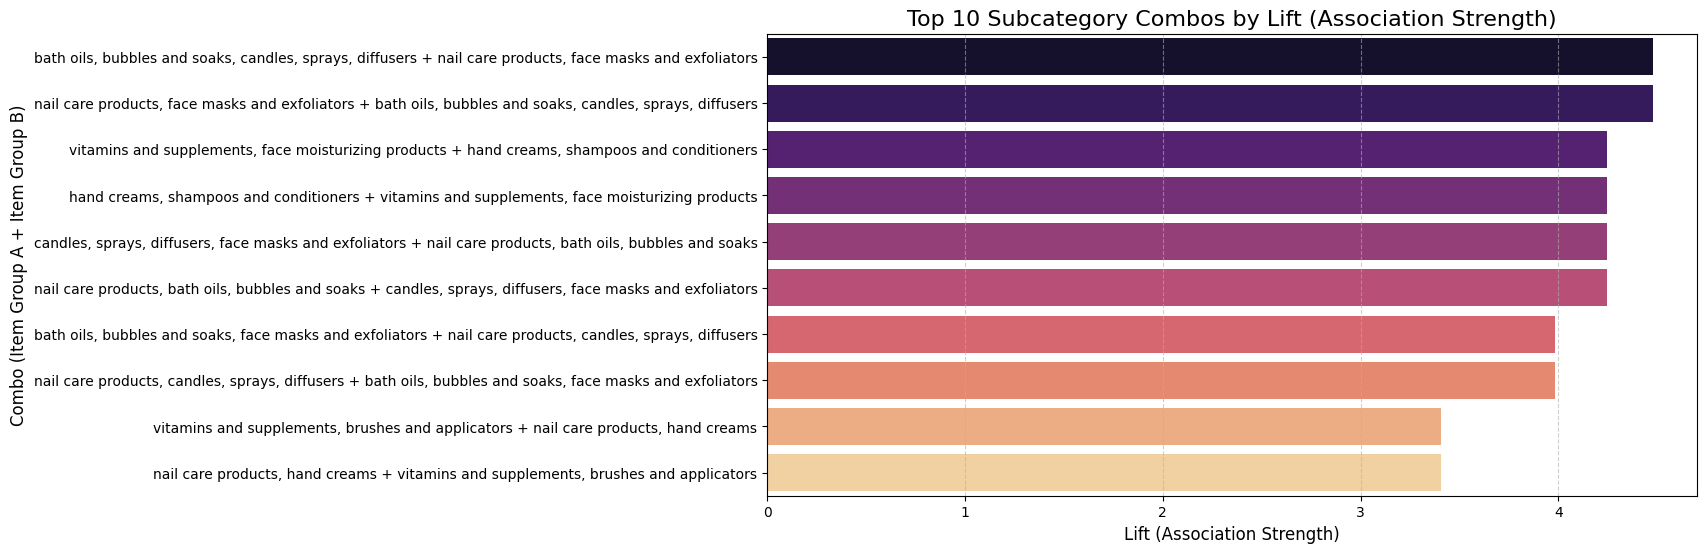

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_rules, x='lift', y= 'Combo', palette='magma')
plt.title('Top 10 Subcategory Combos by Lift (Association Strength)', fontsize=16)
plt.xlabel('Lift (Association Strength)', fontsize=12)
plt.ylabel('Combo (Item Group A + Item Group B)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# **4. FP Growth**

### **Step 1: Run FP-Growth Algorithm**
After preparing the data, we will use the **FP-Growth (Frequent Pattern Growth)** algorithm. To save time and keep things consistent, we will reuse the `df_encoded` matrix that we created earlier for the Apriori algorithm.

Compared to Apriori, FP-Growth is much faster and uses less memory because it stores the dataset in a tree structure without generating candidate itemsets. We will keep using `min_support=0.001` to find the popular groups of items.

In [ ]:
frequent_itemsets = fpgrowth(
    df_encoded,
    min_support=0.001,
    use_colnames=True,
)

In [ ]:
print("Frequent Itemsets:", frequent_itemsets.shape[0])
print(frequent_itemsets.sort_values('support', ascending=False).head(10))

Frequent Itemsets: 612
     support                        itemsets
2   0.199122            (nail care products)
4   0.160836     (shampoos and conditioners)
9   0.147582  (bath oils, bubbles and soaks)
0   0.146883                   (hand creams)
10  0.143812             (body moisturizers)
5   0.128887      (vitamins and supplements)
7   0.123406       (eye shadows and pencils)
12  0.115866    (face moisturizing products)
1   0.113495    (face masks and exfoliators)
8   0.094644       (brushes and applicators)


### **Step 2: Extract and Filter Association Rules**
Now, we generate association rules from the frequent itemsets using the `lift` metric. To make sure we only get the most meaningful and high-quality business insights, we will apply the following filters:
- `support >= 0.001`: The combo must appear in at least 0.1% of all transactions.
- `confidence >= 0.1`: There is at least a 10% chance that a customer buys the second product group after buying the first one.
- `lift >= 1.2`: The relationship between the product groups must be strong and not random.

In [ ]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

In [ ]:
rules = rules[
    (rules['support'] >= 0.001) &
    (rules['confidence'] >= 0.1) &
    (rules['lift'] >= 1.2)
]

In [ ]:
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)
print("\nAssociation Rules:", rules.shape[0])


Association Rules: 1065


In [ ]:
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
0,"(candles, sprays, diffusers, face masks and ex...","(nail care products, bath oils, bubbles and so...",0.001011,0.118182,4.246623
1,"(nail care products, bath oils, bubbles and so...",(face masks and exfoliators),0.001011,0.346667,3.054466
2,"(candles, sprays, diffusers, nail care product...","(bath oils, bubbles and soaks)",0.001011,0.419355,2.841496
3,"(hand creams, shampoos and conditioners, face ...","(bath oils, bubbles and soaks)",0.001049,0.391304,2.651430
4,"(nail care products, bath oils, bubbles and so...","(candles, sprays, diffusers)",0.001011,0.208000,2.606636
...,...,...,...,...,...
1060,"(body moisturizers, bath oils, bubbles and soaks)",(shampoos and conditioners),0.003848,0.193359,1.202211
1061,"(vitamins and supplements, hand creams)","(bath oils, bubbles and soaks)",0.003148,0.177243,1.200976
1062,"(body soaps and washes, face masks and exfolia...",(nail care products),0.001710,0.239130,1.200927
1063,"(foundations and concealers, accessories)",(eye shadows and pencils),0.001088,0.148148,1.200490


### **Step 3: Visualize Top 10 Product Combinations**
To easily understand the results, we will select the top 10 rules with the highest `lift` scores. We will combine the names of the product groups into a readable format and create a horizontal bar chart to show the strongest connections.

/tmp/ipykernel_2320/2265973155.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_fpgrowth_rules['Combo'] = top_10_fpgrowth_rules['antecedents'].apply(lambda x: ', '.join(list(x))) + ' + ' + \
/tmp/ipykernel_2320/2265973155.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_fpgrowth_rules, x='lift', y='Combo', palette='magma')


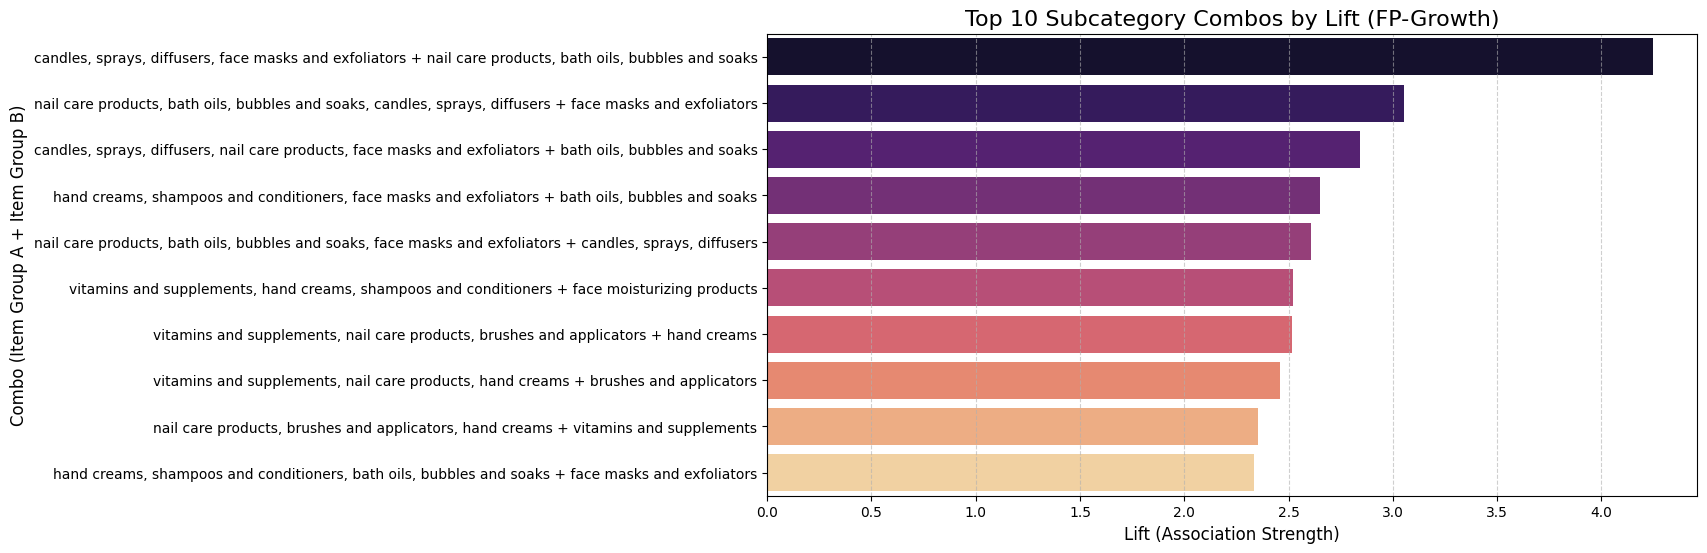

In [ ]:
top_10_fpgrowth_rules = rules.head(10)
top_10_fpgrowth_rules['Combo'] = top_10_fpgrowth_rules['antecedents'].apply(lambda x: ', '.join(list(x))) + ' + ' + \
                                 top_10_fpgrowth_rules['consequents'].apply(lambda x: ', '.join(list(x)))

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_fpgrowth_rules, x='lift', y='Combo', palette='magma')
plt.title('Top 10 Subcategory Combos by Lift (FP-Growth)', fontsize=16)
plt.xlabel('Lift (Association Strength)', fontsize=12)
plt.ylabel('Combo (Item Group A + Item Group B)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# 📊 **5. Results Analysis**

## 5.1 Strongest Product Combinations (Top Lift)

Based on the chart, we can see some clear shopping trends:

**🏆 Combo #1: [Nail care, face masks, exfoliators] + [Bath oils, bubbles, soaks, candles, sprays, diffusers]**
- Lift ≈ 4.5 → Customers buying the first group are 4.5 times more likely to buy the second group compared to a random choice.
- **Shopping Psychology:** This combo represents a "Self-Care & Home Spa" trend. Customers who want to pamper themselves with nail care or face masks also want to create a relaxing atmosphere at home with scented candles and bath oils. They are looking for a complete relaxation experience.

**🥈 Combo #2: [Vitamins, supplements, face moisturizing] + [Hand creams, shampoos, conditioners]**  
- Lift ≈ 4.25 → Customers buying health and facial skincare products are 4.25 times more likely to buy hair and hand care products.
- **Shopping Psychology:** This reflects a "Total Beauty & Wellness Routine." These customers are highly focused on personal health and grooming. When they buy vitamins or facial moisturizers, they often want to complete their daily self-care routine by purchasing hair and hand care items at the same time.

### 5.2 Notable Shopping Patterns
- **The "Home Spa" Trend Dominates:** Products related to relaxation (bath oils, candles, diffusers) and personal grooming (nail care, face masks) appear together frequently at the top of the list.
- **Cross-Category Buying:** Customers do not just buy one type of product; they love to connect health supplements with outer beauty products (skincare, hair care), showing a strong demand for all-in-one care packages.

# 📊 6. Observations & Recommendations

## **6.1 Customer Psychology & Actionable Recommendations**

By looking at the Top 10 combos from both models, we can identify **two main customer groups** and clear ways to drive sales:

---

#### 🧠 Part 1: Customer Psychology Behind the Combos

**🛁 Group 1 — Self-care (Dominates the Top Combos)**  
* **Combo:** `Bath oils + Candles/Diffusers + Face masks + Nail care`  
* **Behavior:** These customers plan their shopping ahead of time for a complete "home spa". They want to soak in the tub (`bath oils`), relax with nice scents (`candles/diffusers`), take care of their skin (`face masks`), and do their nails (`nail care`). If they miss one item, they are very likely to add it to the cart to complete the experience.

**💊 Group 2 — Beauty From Within (Appears in Top 5–10)**  
* **Combo:** `Vitamins/Supplements + Hand creams + Face moisturizing + Brushes`  
* **Behavior:** These customers focus on total health and beauty. They combine internal health (`vitamins`) with external skincare (`hand creams`, `face moisturizing`) and use proper tools (`brushes and applicators`). This group has high brand loyalty—they shop with a clear routine rather than just chasing discounts.

---

#### 🚀 Part 2: Strategic Recommendations for Stakeholders

**🏪 1. Launch Bundles Instead of Simple Combos**  
* Package `Bath oils + Candles + Face masks + Nail care` into a curated set named **"Self-Care Kit"**. Using emotional names works better than just listing product titles.
* *Suggested Discount:* **10–15%** for the full 4-item set, and **5–8%** for a 3-item mix. These ranges are starting points and should be validated through A/B testing to find the optimal level.

**💻 2. Use Contextual Product Recommendations on the Website**  
* When a customer visits a `Bath oils` page, show a popup: *"Complete your relaxing evening"* featuring Candles + Face masks.  
* When a customer buys `Vitamins`, suggest `Hand creams + Face moisturizing` under the theme *"Beautiful from the inside out"*.

**📧 3. Run Targeted Email Remarketing Campaigns**  
* Track customers who already bought **2 out of 4 items** from the Self-Care combo.
* Send them a friendly email reminding them to complete their routine with the missing items, along with a limited-time discount voucher. Based on the strong lift scores of this combo, this group is expected to have a higher conversion rate because they already buy into the routine.

## **6.2. Comparison Between Apriori and FP-Growth**

After using the exact same parameters (`min_support=0.001`, `confidence >= 0.1`, `lift >= 1.2`), the results of both models **clearly converge** — they find the same core product groups and show the same overall priority.

**Similarities:**
- The strongest top combo in both models is the group of 4 subcategories: `bath oils + candles/diffusers + face masks + Nail care`. This proves that this connection is **truly meaningful** and does not depend on which algorithm we use.
- The group of `hand creams + vitamins/supplements + brushes and applicators` appears consistently in the Top 10 of both models.

**Differences:**
- **Apriori** shows slightly higher Lift scores (~4.5 compared to ~4.2 in FP-Growth). This is because its candidate generation process checks all possible combinations, allowing it to capture exact sub-patterns with maximum lift more accurately.
- **FP-Growth** discovers an additional combo: `hand creams + bath oils + shampoos + face masks` which does not appear in Apriori. This pattern has a good support score but a moderate lift. The FP-tree structure can find it by searching through branches instead of looking at item pairs.

> **Conclusion:** The convergence of both models is a very good sign. It means the discovered product combos are **reliable and ready to use** for business strategies, rather than just a random result from a single algorithm.

# 📊 7. Business Impact Estimate & Limitations

## 7.1 Sizing the Opportunity (Order of Magnitude, Not a Forecast)

The strongest rule found — `bath oils, bubbles and soaks + candles, sprays, diffusers` ↔
`Nail care products, face masks and exfoliators` — has **support ≈ 0.10%** and
**lift ≈ 4.48**. In plain terms: out of every ~1,000 orders, roughly 1 already contains this
exact combo, and a customer who buys one side of it is about **4.5x more likely** than
random to also buy the other side.

This is a real, non-random signal — but the *base rate* is small. Before pitching a
company-wide rollout, size the actual addressable population, e.g.:

```python
# Example: how many customers bought ONE side of the top combo but not the other?
# (a rough proxy for the addressable remarketing audience mentioned in Section 6.1)
partial_buyers = df_encoded[
    (df_encoded['bath oils, bubbles and soaks'] | df_encoded['candles, sprays, diffusers']) &
    ~(df_encoded['nail care products'] & df_encoded['face masks and exfoliators'])
]
print(f"Orders that could plausibly be upsold into the full combo: {len(partial_buyers)}")
```

Run this before committing a promotion budget — a lift of 4.5x on a support of 0.1% can
still mean a very small number of orders in absolute terms, which changes whether this
justifies a dedicated bundle SKU vs. just a website recommendation module.

## 7.2 Limitations to Disclose Alongside the Recommendations

- **Association ≠ causation.** These rules describe co-purchase patterns, not the effect of
  *placing* items together. A bundle discount could increase attach rate — or it could just
  give a discount to people who were already going to buy both. Only an A/B test resolves this.
- **Subcategory grain hides SKU-level detail.** "Nail care products" bundles hundreds of
  distinct products together (Section 2 notes 3,577 products / 17 subcategories). A rule at
  this level tells Merchandising *which shelf* to link, not *which specific SKU* to feature —
  a follow-up product-level cut within the top subcategory pairs is needed before finalizing
  bundle contents.
- **No seasonality or promotion control.** The dataset spans multiple years (2020–2023 in the
  sample rows) without controlling for holidays, prior promotions, or stockouts that could
  inflate or suppress co-purchase rates in ways unrelated to genuine product affinity.
- **No price/margin data joined in.** A high-lift combo is not automatically a
  high-*profit* combo — before setting the 10–15% bundle discount proposed in Section 6.1,
  confirm margin can absorb it (the companion ABC/RFM/Cohort analysis already has
  `Profit`/`Revenue` at the customer level and could be extended to the subcategory level
  for this check).

## 7.3 Recommended Next Steps

1. **Pilot, don't roll out.** Test the "Self-Care Kit" bundle (Section 6.1) on a limited
   audience/time window before a full launch, with a holdout group to isolate the bundle's
   true lift on revenue — not just its co-purchase support.
2. **Prioritize the pilot audience using the companion RFM analysis.** Customers already
   flagged as **Champions** or **Loyal** are more likely to respond predictably to a bundle
   offer than colder segments, making them a lower-risk group to validate the bundle concept
   with first.
3. **Re-run this notebook on a rolling basis.** Association rules can drift as the catalog
   and seasonality change — treat `min_support`/`min_threshold` as parameters to revisit,
   not fixed constants.
